# Notebook 2: Associating our dataset with country and administrative divisions

**CCOM 6994: Data Analysis Tools - Final Project**  
**Course: Análisis de Datos de Paneles Solares**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Retrieve dataset** saved in local database file (`db/pv_project.ddb`).
2. **Perform reverse geocoding** to assign country level information to each polygon label.
3. **Fetch administrative divisions** from Overture Maps using country ISO codes to optimize the search.
4. **Implement spatial indexing** (R-Tree) in both GeoPandas and DuckDB to improve performance.
5. **Save optimized data** as spatially partitioned GeoParquet and DuckDB tables.
6. **Enrich PV dataset** by spatially joining with administrative divisions.

---

## 🔧 Setup: Import Libraries

In [1]:
import os
import time
import random


import pandas as pd
import numpy as np
import duckdb
import geopandas as gpd
from shapely import wkt
from shapely.geometry import box, Point, Polygon, MultiPolygon
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from tqdm import tqdm

# Optional: Reverse Geocoder for offline fast geocoding
try:
    import reverse_geocoder as rg
    REVERSE_GEOCODER_AVAILABLE = True
except ImportError:
    print("⚠️ reverse-geocoder not installed. Install with `pip install reverse_geocoder`.")
    REVERSE_GEOCODER_AVAILABLE = False
import censusdis.data as ced
import censusdis.maps as cem
from censusdis.states import IDS_FROM_NAMES, ABBREVIATIONS_FROM_IDS, NAMES_FROM_IDS


# Load environment variables
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')

---

## 📥 Task 1: Retrieve Data from Local DuckDB

In the previous notebook, we saved our processed solar panel data to a local DuckDB file `db/pv_project.ddb`. We will now load it back.

In [2]:
DB_PATH = os.getenv('PROJECT_DB', 'db/pv_project.ddb')

PROJECT_AOI = os.getenv('PROJECT_AOI', '-161.0,17.8,-65.2,47.8')
PROJECT_AOI = (float(p) for p in PROJECT_AOI.split(','))

print(f"📂 Connecting to database: {DB_PATH}")

# Connect to the database
con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")

# Check available tables
tables = con.execute("SHOW TABLES").fetchall()
print(f"   Tables found: {[t[0] for t in tables]}")

# Load the processed PV data
# We use read_sql to get a DataFrame, then convert to GeoDataFrame
print("   Loading 'processed_pv_data'...")
pv_df = con.execute("SELECT * FROM processed_pv_data").df()

# Convert WKT to Geometry
if 'geometry' in pv_df.columns:
    pv_df['geometry'] = pv_df['geometry'].apply(wkt.loads)
    pv_gdf = gpd.GeoDataFrame(pv_df, geometry='geometry', crs='EPSG:4326')
    print(f"✅ Loaded {len(pv_gdf):,} rows into GeoDataFrame.")
else:
    print("❌ Error: No geometry column found.")

con.close() # Close for now, we'll reopen later

📂 Connecting to database: db/pv_project.ddb
   Tables found: ['admin_div_geom', 'administrative_divisions', 'census_acs5_county_2020', 'census_acs5_state_2020', 'enriched_pv_data', 'processed_pv_data', 'pv_geom']
   Loading 'processed_pv_data'...
✅ Loaded 41,867 rows into GeoDataFrame.


---

## 🌍 Task 2: Reverse Geocoding (Country Assignment)

We need to know which country each solar panel belongs to. This allows us to:
1. Perform country-specific analysis.
2. Optimize our queries to external datasets (like Overture Maps) by filtering by country.

We use **Offline Reverse Geocoding** (`reverse_geocoder`) because it is extremely fast and doesn't require API keys or internet access for every point.

In [3]:
BBOX_ROWS = 0
if REVERSE_GEOCODER_AVAILABLE:
    print("🌍 Running Offline Reverse Geocoding...")
    
    # Prepare coordinates (Lat, Lon)
    # reverse_geocoder expects a list of tuples
    coords = list(zip(pv_gdf['centroid_lat'], pv_gdf['centroid_lon']))
    BBOX_ROWS = len(coords)
    
    t1 = time.time()
    results = rg.search(coords)
    t2 = time.time()
    
    # Extract Country Code (ISO 3166-1 alpha-2)
    # results is a list of OrderedDicts, 'cc' is the country code key
    pv_gdf['country_code'] = [r['cc'] for r in results]
    # save state and county as well and format column names for censusdis
    pv_gdf['rg_state'] = [r['admin1'] for r in results]
    pv_gdf['rg_county'] = [r['admin2'] for r in results]


    print(f"✅ Geocoded {BBOX_ROWS:,} points in {t2 - t1:.2f}s using reverse_geocoder library.")

    # Show distribution
    print("\n📊 Top Countries found:")
    print(pv_gdf['country_code'].value_counts().head(5))

    # print top states/regions as well
    print("\n📊 Top States found:")
    print(pv_gdf['rg_state'].value_counts().head(10))

else:
    print("⚠️ Skipping reverse geocoding (library not found).")
    # Fallback: Assume US for demo purposes if column doesn't exist
    if 'country_code' not in pv_gdf.columns:
        pv_gdf['country_code'] = 'US'

🌍 Running Offline Reverse Geocoding...
Loading formatted geocoded file...
✅ Geocoded 41,867 points in 1.62s using reverse_geocoder library.

📊 Top Countries found:
country_code
US    41121
CA      588
MX       79
PR       62
VI        9
Name: count, dtype: int64

📊 Top States found:
rg_state
California        24697
Arizona            5796
North Carolina     1309
Massachusetts      1285
Colorado           1217
New Jersey         1208
New Mexico          951
Texas               611
Nevada              590
Ontario             568
Name: count, dtype: int64


In [4]:
# compare to online/API reverse geocoding via geopy and geopandas
# parse list of (lat, lon) tuples as shapely Points
t1 = time.time()
gpd.tools.reverse_geocode([Point(lon, lat) for lat, lon in coords[:15]])
t2 = time.time()
print(f"✅ Geocoded 15 points in {t2 - t1:.2f}s using geopandas reverse_geocode.")

✅ Geocoded 15 points in 18.60s using geopandas reverse_geocode.


In [5]:
# show admin info from offline reverse geocoder
pd.DataFrame(results).head()

,lat,lon,name,admin1,admin2,cc
0,47.68128,-117.28271,Millwood,Washington,Spokane County,US
1,42.41555,-96.41836,Dakota City,Nebraska,Dakota County,US
2,40.0789,-93.61661,Trenton,Missouri,Grundy County,US
3,44.78274,-93.91358,Young America (historical),Minnesota,Carver County,US
4,45.1033,-93.69135,Greenfield,Minnesota,Hennepin County,US


## 📥 Task 2.5: Refining Location Geometries via US Census Geographies

We will use the US Census Bureau's API via the `censusdis` [python library](https://pypi.org/project/censusdis/) to refine our location geometries for points in the United States. This will help us get more accurate administrative boundaries for our solar panel locations and optimize any further fetching we need to perform from Overture Maps.

In [6]:
# 1. Get unique countries
unique_countries = pv_gdf['country_code'].unique().tolist()
print(f"🌐 Unique Countries Found: {unique_countries}")
# only keep US, PR, VI, GU for our AOIs
unique_countries = [c for c in unique_countries if c in ['US', 'PR', 'VI', 'GU']]
print(f"🎯 Target Countries: {unique_countries}")

# filter dataset to only these countries
pv_gdf = pv_gdf[pv_gdf['country_code'].isin(unique_countries)].copy()
print(f"📊 Filtered GeoDataFrame now has {len(pv_gdf)} rows.")
print(f"Removed {BBOX_ROWS - len(pv_gdf)} rows outside target countries.")
# group by country and state to see counts
country_state_counts = pv_gdf.groupby(['country_code', 'rg_state']).size().sort_values(ascending=False).reset_index(name='counts')
print("📊 Counts by Country and State:")
print(country_state_counts)

🌐 Unique Countries Found: ['US', 'CA', 'MX', 'PR', 'VG', 'VI', 'GU', 'DO']
🎯 Target Countries: ['US', 'PR', 'VI', 'GU']
📊 Filtered GeoDataFrame now has 41196 rows.
Removed 671 rows outside target countries.
📊 Counts by Country and State:
   country_code        rg_state  counts
0            US      California   24697
1            US         Arizona    5796
2            US  North Carolina    1309
3            US   Massachusetts    1285
4            US        Colorado    1217
..          ...             ...     ...
74           PR      Juana Diaz       1
75           US    South Dakota       1
76           PR           Cayey       1
77           US    North Dakota       1
78           PR           Ceiba       1

[79 rows x 3 columns]


Fetched 56 state geometries from US Census shapefiles: 
['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Commonwealth of the Northern Mariana Islands', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'United States Virgin Islands', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198560935,726482115,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196345992286,3383664203,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403671196038,20294133830,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102282796080,2368025703,"MULTIPOLYGON (((-89.41728 36.49901, -89.40565 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131175460655,4591915034,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."


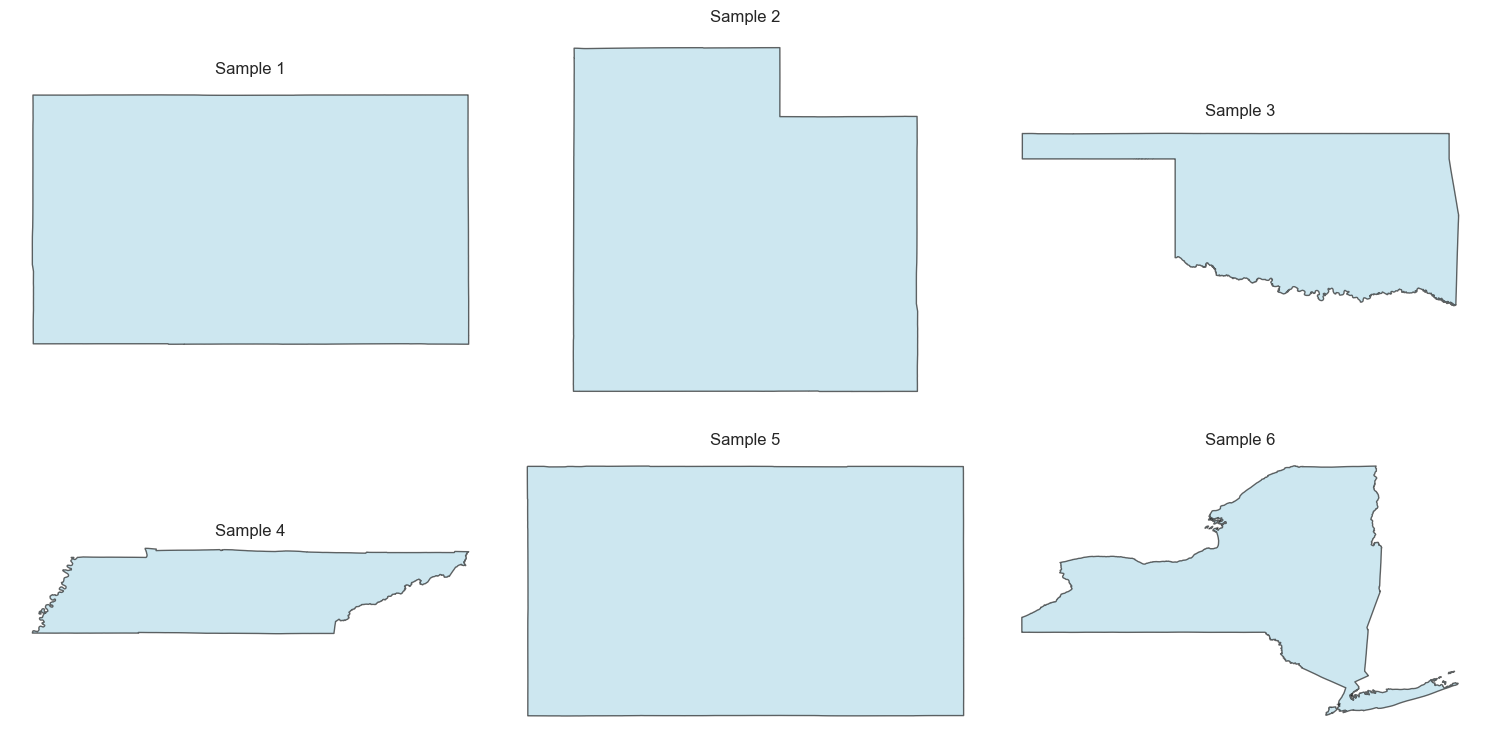

In [7]:
# following geography + geometry tutorial from: https://censusdis.readthedocs.io/en/latest/nb/Data%20With%20Geometry.html
# and API references for data module: https://censusdis.readthedocs.io/en/latest/data.html
# and maps module: https://censusdis.readthedocs.io/en/latest/maps.html

reader = cem.ShapeReader(year=2020)
gdf_state_bounds = reader.read_cb_shapefile(shapefile_scope="us", geography="state", crs="EPSG:4326")
print(f"Fetched {len(gdf_state_bounds):,} state geometries from US Census shapefiles: \n{sorted(gdf_state_bounds['NAME'].unique().tolist())}")
gdf_state_bounds.head()

# visualize 2x6 subplot of state geometries
display(gdf_state_bounds.head())
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
# randomly sample geometries
rand_idx = random.randint(0, len(gdf_state_bounds)-6)
geom_sample = gdf_state_bounds.iloc[rand_idx:rand_idx+6]["geometry"]
# iterate and plot each geometry using GeoSeries plot
for i, geom in enumerate(geom_sample):


    gpd.GeoSeries([geom]).plot(ax=axes[i], color='lightblue', edgecolor='black', alpha=0.6)
    axes[i].set_title(f"Sample {i+1}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


---

## ⚡ Geopandas: Spatial Indexing

Spatial indexing significantly speeds up spatial queries (like "which county is this point in?").

### 4.1 GeoPandas Spatial Index (R-Tree)
GeoPandas automatically builds an R-Tree index when you use spatial methods like `.cx` or `sjoin`.

In [8]:
# perform spatial join to find nearest state geometries and keep census FIPS codes and GEOIDs
pv_enriched_gdf = pv_gdf.sjoin(gdf_state_bounds, how='left', predicate='within')

In [9]:
# save rows that failed to match and find their FIDS via censusdis states module (does not work for GU, VI)1
unmatched_pv = pv_enriched_gdf[pv_enriched_gdf['STATEFP'].isna()]
# drop unmatched rows from main gdf
pv_enriched_gdf = pv_enriched_gdf[~pv_enriched_gdf['STATEFP'].isna()]

print(f"✅ After spatial join, we have {len(unmatched_pv) } unmatched rows from the following states we will match by state name from reverse geocoder:\n {unmatched_pv['rg_state'].unique().tolist()} ")

✅ After spatial join, we have 43 unmatched rows from the following states we will match by state name from reverse geocoder:
 ['Minnesota', 'New York', 'New Mexico', 'Michigan', 'Massachusetts', 'California', 'Washington', 'Texas', 'Maine'] 


In [10]:
unmatched_pv.head(2)

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date,lat_band,h3_highres,country_code,rg_state,rg_county,index_right,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER
134,global_pv_inventory_sent2_spot_2021,2025-09-25 23:24:11.103000-04:00,"POLYGON ((-94.25189 48.7076, -94.25325 48.7075...",281401.732314,48.709028,-94.254008,613176616025063423,63140.0,122535.252717,9.080349,<2016-06,NaN,644701813414942612,US,Minnesota,Lake of the Woods County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2044,global_pv_inventory_sent2_spot_2021,2025-09-25 23:24:11.103000-04:00,"POLYGON ((-75.00318 45.00583, -75.00318 45.005...",27139.055034,45.006644,-75.001840,613255811052863487,26617.0,13566.379801,1.141651,<2016-06,Far North (45-48°N),644781008442727576,US,New York,St. Lawrence County,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
state_nan_cols = gdf_state_bounds.columns.tolist()[:-1] + ['index_right']

# drop any rows we can't match with censusdis states (+ DC and PR)
unmatched_pv = unmatched_pv[unmatched_pv["country_code"].isin(['US', 'PR'])]
# drop nan columns from unmatched join
unmatched_pv.drop(labels=state_nan_cols, axis='columns', inplace=True)
# create a STATE column same as rg_state except cases where country_code is PR, then set STATE to 'PR'
unmatched_pv["STATE"] = unmatched_pv.apply(lambda row: 'Puerto Rico' if row["country_code"] == 'PR' else row["rg_state"], axis=1)
unmatched_pv["STATE"] = unmatched_pv.apply(lambda row: 'District of Columbia' if row["rg_state"] == 'Washington, D.C.' else row["STATE"], axis=1)
# add FIPS codes and only keep state abbreviation column
unmatched_pv["STATEFP"] = unmatched_pv["STATE"].map(lambda x: IDS_FROM_NAMES[x])
# get state abbreviations for census geometry fetch later
unmatched_pv["STUSPS"] = unmatched_pv["STATEFP"].map(lambda x: ABBREVIATIONS_FROM_IDS[x])

# fetch GEOIDs for states from state_bounds gdf
matched_leftovers = unmatched_pv.merge(gdf_state_bounds[['STATEFP', 'GEOID', 'NAME']], on='STATEFP', how='inner', suffixes=('', '_state'))

In [12]:
# print(len(matched_leftovers))
# matched_leftovers.head()

In [13]:
# only keep original pv_gdf columns + STATEFP, STUSPS, GEOID renamed to STATE_FIPS, STATE_ABBR, STATE_GEOID
pv_enriched_gdf = pv_enriched_gdf[list(pv_gdf.columns) + ['STATEFP', 'STUSPS', 'GEOID']]
# same for unmatched_pv and perform concat/union
matched_leftovers = matched_leftovers[list(pv_gdf.columns) + ['STATEFP', 'STUSPS', 'GEOID']]
# rename columns after concat
pv_enriched_gdf = pd.concat([pv_enriched_gdf, matched_leftovers], ignore_index=True)
pv_enriched_gdf = pv_enriched_gdf.rename(columns={
    'STATEFP': 'STATE_FIPS',
    'STUSPS': 'STATE_ABBR',
    'GEOID': 'STATE_GEOID'
})
# handle geometry column after concat
pv_enriched_gdf = gpd.GeoDataFrame(pv_enriched_gdf, geometry='geometry', crs='EPSG:4326')

In [14]:
pv_enriched_gdf.sample(3)

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date,lat_band,h3_highres,country_code,rg_state,rg_county,STATE_FIPS,STATE_ABBR,STATE_GEOID
33037,usa_cali_usgs_pv_2016,2025-09-25 23:24:58.477000-04:00,"POLYGON ((-119.71371 36.72663, -119.71371 36.7...",10.080148,36.726630,-119.713733,613222621365927935,12515,NaN,NaN,None,Mid (35-40°N),644747818756030856,US,California,Fresno County,06,CA,06
9751,global_harmonized_large_solar_farms_2020,2025-09-25 23:23:57.416000-04:00,"POLYGON ((-104.87369 39.53509, -104.87364 39.5...",571.354692,39.534955,-104.873599,613167728420716543,19846,NaN,NaN,None,Mid (35-40°N),644692925810419933,US,Colorado,Adams County,08,CO,08
13833,usa_cali_usgs_pv_2016,2025-09-25 23:24:58.477000-04:00,"POLYGON ((-119.7853 36.73531, -119.7853 36.735...",40.404976,36.735325,-119.785338,613222621523214335,13101,NaN,NaN,None,Mid (35-40°N),644747818913170292,US,California,Fresno County,06,CA,06


In [15]:
# verify there are no pv labels with no state fips
assert pv_enriched_gdf['STATE_FIPS'].isna().sum() == 0, "❌ Some PV labels have no STATE_FIPS assigned!"
print("✅ All PV labels have STATE_FIPS assigned.")

✅ All PV labels have STATE_FIPS assigned.


Fetched 3,234 county geometries from US Census shapefiles.


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558..."
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162..."
3,13,189,00348794,0500000US13189,13189,McDuffie,McDuffie County,GA,Georgia,06,666590014,23114032,"POLYGON ((-82.64852 33.60838, -82.64409 33.606..."
4,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804..."


Using counties sampled from state Wyoming for visualization:


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_15858/3594744732.py:17: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries([]).plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)


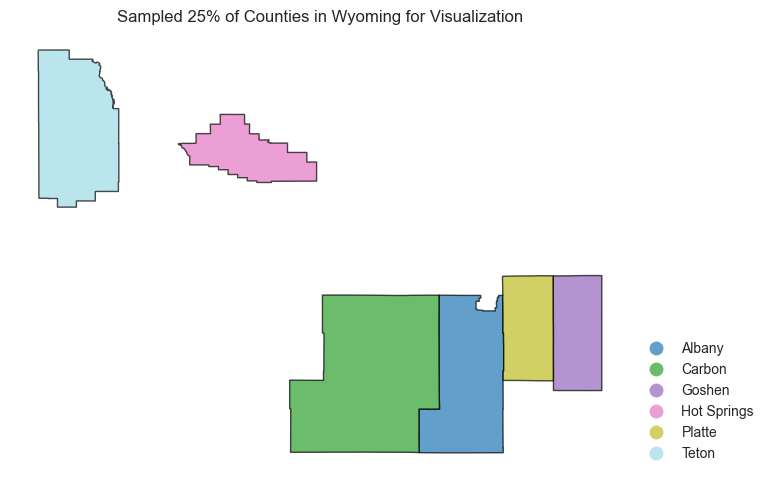

In [ ]:
county_sample_pct = 0.25  # 25% sample of counties for visualization

# perform the same exercise of saving associated census identifiers, but this time with geometries for state counties
county_bounds_gdf = reader.read_cb_shapefile(shapefile_scope="us", geography="county", crs="EPSG:4326")
print(f"Fetched {len(county_bounds_gdf):,} county geometries from US Census shapefiles.")
display(county_bounds_gdf.head())
# sample one of the 6 states we used for visualization
rand_state_idx = random.randint(rand_idx, rand_idx + 5)
sample_state_fips = gdf_state_bounds.iloc[rand_state_idx]['STATEFP']
sample_state_bounds = gdf_state_bounds.iloc[rand_state_idx]['geometry']
print(f"Using counties sampled from state {gdf_state_bounds.iloc[rand_state_idx]['NAME']} for visualization:")
# sample county bounds to only this state
sample_county_bounds = county_bounds_gdf[county_bounds_gdf['STATEFP'] == sample_state_fips].sample(frac=county_sample_pct, random_state=42)
# plot state polygon and sampled counties within the state geometry
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# plot state boundary
gpd.GeoSeries([]).plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)
# plot sampled counties; place legend outside the plot and at bottom
sample_county_bounds.plot(ax=ax, column='NAME', cmap='tab20', edgecolor='black', alpha=0.7, legend=True, legend_kwds={'loc': 'lower left', 'bbox_to_anchor': (1.0, 0)})
ax.set_title(f"Sampled {county_sample_pct * 100:.0f}% of Counties in {gdf_state_bounds.iloc[rand_state_idx]['NAME']} for Visualization")
ax.axis('off')
plt.show()

In [17]:
pv_state_cols = pv_enriched_gdf.columns.tolist()
pv_enriched_gdf = pv_enriched_gdf.sjoin(county_bounds_gdf, how='left', predicate='within')

In [18]:
# check if any rows failed to match
unmatched_counties = pv_enriched_gdf[pv_enriched_gdf['COUNTYFP'].isna()]
# drop unmatched rows from main gdf
og_len = len(pv_enriched_gdf)
pv_enriched_gdf = pv_enriched_gdf[~pv_enriched_gdf['COUNTYFP'].isna()]

print(f"✅ After spatial join with counties, we have {len(unmatched_counties)} unmatched rows.")

✅ After spatial join with counties, we have 100 unmatched rows.


In [19]:
county_cols_to_keep = ['COUNTYFP', 'GEOID', 'NAME'] 

# for these we will use sjoin_nearest with the counties_gdf filtered to the states of the unmatched rows
if len(unmatched_counties) > 0:

    # list of columns to drop; make sure to exclude geometry 
    county_nan_cols = county_bounds_gdf.columns.tolist()[:-1] + ['index_right']

    # drop all the nan columns from unmatched join
    unmatched_counties.drop(labels=county_nan_cols, axis='columns', inplace=True)

    county_join_cols = ['COUNTYFP', 'GEOID', 'NAME', 'geometry'] 

    # get unique state fips from unmatched rows
    unmatched_state_fips = unmatched_counties['STATE_FIPS'].unique().tolist()
    print(f"Attempting to match unmatched counties using sjoin_nearest for states: {[NAMES_FROM_IDS[s] for s in unmatched_state_fips]}")
    # filter county bounds to only these states
    filtered_county_bounds = county_bounds_gdf[county_bounds_gdf['STATEFP'].isin(unmatched_state_fips)]

    # convert to projected CRS for distance calculations in meters
    unmatched_counties = unmatched_counties.to_crs(epsg=3857)
    filtered_county_bounds = filtered_county_bounds.to_crs(epsg=3857)

    # only perform sjoin_nearest with the county geoms for that state
    matched_counties_dfs = []
    for state_fips in unmatched_state_fips:
        state_pv_unmatched_counties = unmatched_counties[unmatched_counties['STATE_FIPS'] == state_fips].copy()
        state_filtered_county_bounds = filtered_county_bounds[filtered_county_bounds['STATEFP'] == state_fips].copy()
        # print(f"pv_unmatched_counties columns (left df): {state_pv_unmatched_counties.columns.tolist()}")
        # print(f"state_filtered_county_bounds columns (right df): {state_filtered_county_bounds.columns.tolist()}")

        # use sindex.nearest to find nearest county geometries: https://geopandas.org/en/stable/docs/reference/api/geopandas.sindex.SpatialIndex.nearest.html
        nearest_county_idxs = state_filtered_county_bounds.sindex.nearest(state_pv_unmatched_counties.geometry, return_all=False)
        # returns 2D array of shape (n_queries, n_results); select indices from second column and grab rows
        county_matches = state_filtered_county_bounds.iloc[nearest_county_idxs[1]][county_cols_to_keep].reset_index(drop=True)
        # assign each column from county_matches to state_pv_unmatched_counties
        for col in county_cols_to_keep:
            # avoid nans from mismatched indices; rely on position via conversion to array or list
            state_pv_unmatched_counties[col] = county_matches[col].to_numpy()
        # display(state_pv_unmatched_counties.head(1))
        matched_counties_dfs.append(state_pv_unmatched_counties)

    # concatenate all matched counties
    nearest_matches = pd.concat(matched_counties_dfs, ignore_index=True)
    # convert to gdf
    nearest_matches = gpd.GeoDataFrame(nearest_matches, geometry='geometry', crs='EPSG:4326')
    print(f"✅ Found {len(nearest_matches[nearest_matches['COUNTYFP'].notnull()])} out of {len(unmatched_counties)} nearest county matches for unmatched rows.")

Attempting to match unmatched counties using sjoin_nearest for states: ['California', 'Massachusetts', 'North Carolina', 'Texas', 'Colorado', 'Florida', 'Utah', 'Virginia', 'New Jersey', 'Maryland', 'Georgia', 'Minnesota', 'Nevada', 'New York', 'New Mexico', 'Michigan', 'Washington', 'Maine']
✅ Found 100 out of 100 nearest county matches for unmatched rows.


In [20]:
# finally concatenate nearest matches to main enriched gdf
pv_enriched_gdf = pv_enriched_gdf[pv_state_cols + county_cols_to_keep]
pv_state_county_gdf = pd.concat([pv_enriched_gdf, nearest_matches], ignore_index=True)
# rename columns after concat
pv_state_county_gdf = pv_state_county_gdf.rename(columns={
    'COUNTYFP': 'COUNTY_FIPS',
    'GEOID': 'COUNTY_GEOID',
    'NAME': 'COUNTY_NAME'
})
pv_state_county_gdf = gpd.GeoDataFrame(pv_state_county_gdf, geometry='geometry', crs='EPSG:4326')

In [21]:
pv_state_county_gdf.sample(3)

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date,lat_band,h3_highres,country_code,rg_state,rg_county,STATE_FIPS,STATE_ABBR,STATE_GEOID,COUNTY_FIPS,COUNTY_GEOID,COUNTY_NAME
26567,usa_cali_usgs_pv_2016,2025-09-25 23:24:58.477000-04:00,"POLYGON ((-121.25468 38.03909, -121.25465 38.0...",23.460939,38.039078,-121.254641,613196956478472191,17532,NaN,NaN,None,Mid (35-40°N),644722153869040526,US,California,San Joaquin County,06,CA,06,077,06077,San Joaquin
35352,usa_cali_usgs_pv_2016,2025-09-25 23:24:58.477000-04:00,"POLYGON ((-119.72812 36.7989, -119.72817 36.79...",220.760736,36.798967,-119.728078,613222621032480767,10600,NaN,NaN,None,Mid (35-40°N),644747818422004301,US,California,Fresno County,06,CA,06,019,06019,Fresno
36113,global_harmonized_large_solar_farms_2020,2025-09-25 23:23:57.416000-04:00,"POLYGON ((-88.48245 48.14712, -88.4825 48.1474...",3675.950024,48.147333,-88.482161,613183391069634559,20524,NaN,NaN,None,NaN,644708588459992169,US,Michigan,Keweenaw County,26,MI,26,083,26083,Keweenaw


In [22]:
assert pv_state_county_gdf['COUNTY_FIPS'].isna().sum() == 0, "❌ Some PV labels have no COUNTY_FIPS assigned!"
print("✅ All PV labels have COUNTY_FIPS assigned.")

✅ All PV labels have COUNTY_FIPS assigned.


Fetched 85,187 tract geometries from US Census shapefiles.


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,06,077,003406,1400000US06077003406,06077003406,34.06,Census Tract 34.06,CA,San Joaquin County,California,CT,839414,14789,"POLYGON ((-121.309 38.02824, -121.30461 38.028..."
1,06,077,004402,1400000US06077004402,06077004402,44.02,Census Tract 44.02,CA,San Joaquin County,California,CT,4346363,0,"POLYGON ((-121.27338 38.10811, -121.27286 38.1..."
2,06,077,004600,1400000US06077004600,06077004600,46,Census Tract 46,CA,San Joaquin County,California,CT,136907222,2007835,"POLYGON ((-121.411 38.23193, -121.40976 38.232..."
3,06,077,001400,1400000US06077001400,06077001400,14,Census Tract 14,CA,San Joaquin County,California,CT,1949841,141296,"POLYGON ((-121.30988 37.98438, -121.30745 37.9..."
4,06,077,003106,1400000US06077003106,06077003106,31.06,Census Tract 31.06,CA,San Joaquin County,California,CT,1633788,254018,"POLYGON ((-121.37304 37.99888, -121.37139 38.0..."


County with most PV installations (1) in Wyoming [GEOID: 56021].


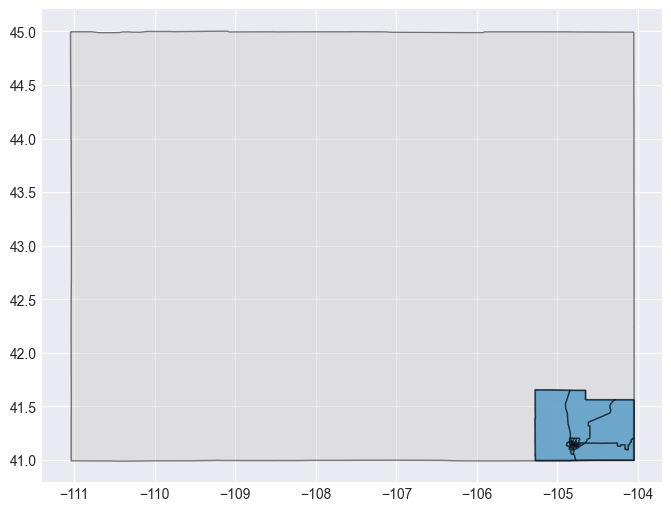

In [23]:
# perform the same exercise but for census tracts
tract_bounds_gdf = reader.read_cb_shapefile(shapefile_scope="us", geography="tract", crs="EPSG:4326")
print(f"Fetched {len(tract_bounds_gdf):,} tract geometries from US Census shapefiles.")
display(tract_bounds_gdf.head())

# plot the previously chosen sample state, the county in that state with the most PV installations (include 0), and all tracts within that county
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# get county with most PV installations in the sample state
sample_state_pv = pv_state_county_gdf[pv_state_county_gdf['STATE_GEOID'] == gdf_state_bounds.iloc[rand_state_idx]['GEOID']]
most_pv_county_geoid = sample_state_pv['COUNTY_GEOID'].value_counts()

# save number of installations in that county and get fips idx
pv_label_count = most_pv_county_geoid.iloc[0]
most_pv_county_geoid = most_pv_county_geoid.index[0]
most_pv_county_name = sample_state_pv['COUNTY_NAME'][sample_state_pv['COUNTY_GEOID'] == most_pv_county_geoid].iloc[0]
print(f"County with most PV installations ({pv_label_count}) in {gdf_state_bounds.iloc[rand_state_idx]['NAME']} [GEOID: {most_pv_county_geoid}].")

# plot state boundary and spatially index so latitude is constrained to the county bounds while longitude spans the state
most_pv_county = county_bounds_gdf[county_bounds_gdf['GEOID'] == most_pv_county_geoid].iloc[0].to_frame().T
most_pv_county = gpd.GeoDataFrame(most_pv_county, geometry='geometry', crs='EPSG:4326')
most_pv_county_bounds = most_pv_county.total_bounds

# make sure indexed selection is a dataframe and not a series
sample_state = gdf_state_bounds.iloc[rand_state_idx].to_frame().T
sample_state = gpd.GeoDataFrame(sample_state, geometry='geometry', crs='EPSG:4326')

# spatial index using latitude bounds of county; recall bbox coords are (minx, miny, maxx, maxy)
state_bounds = sample_state['geometry'].total_bounds
sample_state = sample_state.cx[most_pv_county_bounds[0]:most_pv_county_bounds[2], most_pv_county_bounds[1]:most_pv_county_bounds[3]]
sample_state['geometry'].plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# plot county boundary
most_pv_county_geom = county_bounds_gdf[county_bounds_gdf['GEOID'] == most_pv_county_geoid].iloc[0]['geometry']
gpd.GeoSeries([most_pv_county_geom]).plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7)

# plot tracts within that county; get state intersection then county
tracts_in_county = tract_bounds_gdf[tract_bounds_gdf['STATEFP'].isin(most_pv_county['STATEFP'].unique().tolist())]
tracts_in_county = tracts_in_county[tracts_in_county['COUNTYFP'].isin(most_pv_county['COUNTYFP'].unique().tolist())]
tracts_in_county.plot(ax=ax, edgecolor='black', alpha=0.5)

plt.show()

In [24]:
pv_state_county_cols = pv_state_county_gdf.columns.tolist()
pv_state_county_tract_gdf = pv_state_county_gdf.sjoin(tract_bounds_gdf, how='left', predicate='within')

In [25]:
# grab pv labels that failed to match with census tracts
unmatched_tracts = pv_state_county_tract_gdf[pv_state_county_tract_gdf['TRACTCE'].isna()]
print(f"✅ After spatial join with tracts, we have {len(unmatched_tracts)} unmatched rows.")

pv_state_county_tract_gdf = pv_state_county_tract_gdf[~pv_state_county_tract_gdf['TRACTCE'].isna()]


✅ After spatial join with tracts, we have 486 unmatched rows.


In [26]:
# list of columns to drop; make sure to exclude geometry 
tract_nan_cols = tract_bounds_gdf.columns.tolist()[:-1] + ['index_right']

# drop all the nan columns from unmatched join
unmatched_tracts.drop(labels=tract_nan_cols, axis='columns', inplace=True)

In [27]:
tract_cols_to_keep = ['TRACTCE', 'GEOID', 'NAME']

if len(unmatched_tracts) > 0:

    tract_join_cols = ['TRACTCE', 'GEOID', 'NAME', 'geometry'] 

    # get unique state fips from unmatched rows
    unmatched_state_fips = unmatched_tracts['STATE_FIPS'].unique().tolist()
    state_name_map = unmatched_tracts[['STATE_FIPS', 'STATE_ABBR']].drop_duplicates().to_dict(orient='split')['data']
    # zip to dict
    state_name_map = {item[0]: item[1] for item in state_name_map}
    state_names = [state_name_map[s] for s in unmatched_state_fips]

    print(f"Attempting to match unmatched tracts using sjoin_nearest for states: {state_names}")
    # filter tract bounds to only these states
    filtered_tract_bounds = tract_bounds_gdf[tract_bounds_gdf['STATEFP'].isin(unmatched_state_fips)]

    # convert to projected CRS for distance calculations in meters
    # BUG: conversion to epsg:3857 causes geometries with Infinity coords
    # unmatched_tracts = unmatched_tracts.to_crs(epsg=3857)
    # filtered_tract_bounds = filtered_tract_bounds.to_crs(epsg=3857)

    # only perform sjoin_nearest with the tract geoms for that state
    matched_tracts_dfs = []
    for state_fips in unmatched_state_fips:
        state_pv_unmatched_tracts = unmatched_tracts[unmatched_tracts['STATE_FIPS'] == state_fips].copy()
        state_filtered_tract_bounds = filtered_tract_bounds[filtered_tract_bounds['STATEFP'] == state_fips].copy()

        # print(f"Finding nearest tracts for state {state_name_map[state_fips]} with {len(state_pv_unmatched_tracts)} unmatched rows.")
        # use sindex.nearest to find nearest tract geometries
        nearest_tract_idxs = state_filtered_tract_bounds.sindex.nearest(state_pv_unmatched_tracts.geometry, return_all=False)
        # returns 2D array of shape (n_queries, n_results); select indices from second column and grab rows
        tract_matches = state_filtered_tract_bounds.iloc[nearest_tract_idxs[1]][tract_cols_to_keep].reset_index(drop=True)
        # assign each column from tract_matches to state_pv_unmatched_tracts
        for col in tract_cols_to_keep:
            # avoid nans from mismatched indices; rely on position via conversion to array or list
            state_pv_unmatched_tracts[col] = tract_matches[col].to_numpy()
        # save matched census tracts for each state
        matched_tracts_dfs.append(state_pv_unmatched_tracts)
    
    # concatenate all matched tracts
    nearest_tract_matches = pd.concat(matched_tracts_dfs, ignore_index=True)
    # convert to gdf
    nearest_tract_matches = gpd.GeoDataFrame(nearest_tract_matches, geometry='geometry', crs='EPSG:4326')
    print(f"✅ Found {len(nearest_tract_matches[nearest_tract_matches['TRACTCE'].notnull()])} out of {len(unmatched_tracts)} nearest tract matches for unmatched rows.")

Attempting to match unmatched tracts using sjoin_nearest for states: ['MO', 'CA', 'AZ', 'CT', 'MA', 'RI', 'TX', 'NM', 'PR', 'CO', 'MI', 'NV', 'VT', 'NJ', 'NC', 'MD', 'FL', 'VI', 'NY', 'MN', 'OH', 'IN', 'VA', 'SC', 'PA', 'MS', 'IL', 'HI', 'IA', 'UT', 'GA', 'WA', 'ME']
✅ Found 486 out of 486 nearest tract matches for unmatched rows.


In [28]:
# finally concatenate nearest matches to main enriched gdf
pv_state_county_tract_gdf = pv_state_county_tract_gdf[pv_state_county_cols + tract_cols_to_keep]
pv_final_gdf = pd.concat([pv_state_county_tract_gdf, nearest_tract_matches], ignore_index=True)
# rename columns after concat
pv_final_gdf = pv_final_gdf.rename(columns={
    'TRACTCE': 'TRACT_CODE',
    'GEOID': 'TRACT_GEOID',
    'NAME': 'TRACT_NAME'
})
pv_final_gdf = gpd.GeoDataFrame(pv_final_gdf, geometry='geometry', crs='EPSG:4326')
pv_final_gdf.sample(3)

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date,lat_band,h3_highres,country_code,rg_state,rg_county,STATE_FIPS,STATE_ABBR,STATE_GEOID,COUNTY_FIPS,COUNTY_GEOID,COUNTY_NAME,TRACT_CODE,TRACT_GEOID,TRACT_NAME
39905,global_pv_inventory_sent2_spot_2021,2025-09-25 23:24:11.103000-04:00,"POLYGON ((-120.08354 36.67014, -120.08358 36.6...",14704.258053,36.669827,-120.082827,613222620325740543,nan,NaN,NaN,None,Mid (35-40°N),644747817716834737,US,California,Fresno County,06,CA,06,019,06019,Fresno,003900,06019003900,39
24176,global_pv_inventory_sent2_spot_2021,2025-09-25 23:24:11.103000-04:00,"POLYGON ((-119.26465 36.2184, -119.26463 36.21...",24766.608599,36.218488,-119.263521,613222391763435519,33069.0,16120.024549,1.449462,,Mid (35-40°N),644747589153725032,US,California,Tulare County,06,CA,06,107,06107,Tulare,002402,06107002402,24.02
12450,usa_cali_usgs_pv_2016,2025-09-25 23:24:58.477000-04:00,"POLYGON ((-121.29271 38.05771, -121.29271 38.0...",52.668309,38.057729,-121.292744,613196956677701631,17841,NaN,NaN,None,Mid (35-40°N),644722154067809355,US,California,San Joaquin County,06,CA,06,077,06077,San Joaquin,004108,06077004108,41.08


In [29]:
assert pv_final_gdf['TRACT_GEOID'].isna().sum() == 0, "❌ Some PV labels have no TRACT_GEOID assigned!"
print("✅ All PV labels have TRACT_GEOID assigned.")

✅ All PV labels have TRACT_GEOID assigned.


In [30]:
# final label count and make sure no geometries are invalid
print(f"🎉 Final enriched PV GeoDataFrame has {len(pv_final_gdf)} rows.")
invalid_geoms = pv_final_gdf[~pv_final_gdf.is_valid]
assert len(invalid_geoms) == 0, "❌ Some geometries are invalid!"
print("✅ All geometries are valid.")

🎉 Final enriched PV GeoDataFrame has 41196 rows.
✅ All geometries are valid.


---

## 🗺️ Task 3: Fetching Administrative Divisions from Overture Maps

### [Scope: For International Data outside Project AOI]

**Overture Maps** provides open map data, including administrative boundaries (`division_area`).

Instead of downloading the entire global dataset, we will:
1. Identify the unique countries in our dataset.
2. Use DuckDB to query the Overture S3 bucket directly.
3. Filter by `country` (ISO code) to fetch only relevant divisions.

We are interested in: `country`, `dependency`, `region`, `county`, `locality`.

In [31]:
# Format for SQL query (e.g., 'US', 'PR')
country_list_sql = ", ".join([f"'{c}'" for c in unique_countries])

# 2. Define Overture S3 Path (Public Bucket)
# We use the 'divisions' theme and 'division_area' type
OVERTURE_S3_PATH = "s3://overturemaps-us-west-2/release/2025-11-19.0/theme=divisions/type=division_area/*"

# 3. DuckDB Query
print("\n🦆 Querying Overture Maps via DuckDB...")

# We use an in-memory connection for this fetch to avoid locking the file DB
con_mem = duckdb.connect(':memory:')
con_mem.execute("INSTALL spatial; LOAD spatial;")
con_mem.execute("INSTALL httpfs; LOAD httpfs;")
con_mem.execute("SET s3_region='us-west-2';") # Overture bucket region
# set s3 url style
con_mem.execute("SET s3_url_style='path';")

# Note: We use ST_AsText(geometry) to ensure we get WKT strings, avoiding type errors with binary WKB
query = f"""
    SELECT 
        id as division_id,
        subtype,
        country,
        region,
        names.primary as name,
        ST_AsText(geometry) as geometry
    FROM read_parquet('{OVERTURE_S3_PATH}')
    WHERE country IN ({country_list_sql})
    AND subtype IN ('country', 'dependency', 'region', 'county', 'locality')
"""

t1 = time.time()
divisions_df = con_mem.execute(query).df()
t2 = time.time()

print(f"✅ Fetched {len(divisions_df):,} division features in {t2 - t1:.2f}s")

# Convert to GeoDataFrame
if not divisions_df.empty:
    # Geometry is already WKT string from DuckDB
    divisions_df['geometry'] = divisions_df['geometry'].apply(wkt.loads)
    divisions_gdf = gpd.GeoDataFrame(divisions_df, geometry='geometry', crs='EPSG:4326')
    
    print("\n📊 Divisions by Subtype:")
    print(divisions_gdf['subtype'].value_counts())
    
    display(divisions_gdf.head(3))
else:
    print("⚠️ No divisions found.")


🦆 Querying Overture Maps via DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Fetched 34,146 division features in 227.88s

📊 Divisions by Subtype:
subtype
locality      30654
county         3309
region          175
dependency        6
country           2
Name: count, dtype: int64


,division_id,subtype,country,region,name,geometry
0,9311e831-19b8-4db4-bbfe-520b00d34ee1,locality,US,US-CA,Two Harbors,"POLYGON ((-118.49935 33.4429, -118.49966 33.44..."
1,13889c49-f587-466d-9fcb-4ed36f9fc308,locality,US,US-CA,Rancho Palos Verdes,"POLYGON ((-118.31658 33.7755, -118.31658 33.77..."
2,7140f003-9861-4ed0-9597-7250b6a9dd9e,locality,US,US-CA,Avalon,"POLYGON ((-118.31141 33.32991, -118.31062 33.3..."


In [32]:
# describe divisions table, estimate memory usage, and sample/visualize a shapely geometry
divisions_gdf.describe()
print(f"\n📊 Dataset Overview:")
print(f"   Shape: {divisions_gdf.shape}")
print(f"   Memory: {divisions_gdf.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


📊 Dataset Overview:
   Shape: (34146, 6)
   Memory: 10.2 MB


---

## 💾 Task 5: Saving Optimized Data

We will now save our enriched datasets back to the persistent DuckDB database.

1. **PV Data**: Updated with `country_code` and all the required censsus identifiers and varaibles to fetch state, county, and tract geometries. We will save this enriched data as a new table `pv_solar_enriched` in our DuckDB database.
2. **Divisions Data**: New table `administrative_divisions` which can be used for projects with scopes beyond the United States.
3. **GeoParquet Exports**: We will also export the divisions to a GeoParquet file, [optimized with spatial sorting (Hilbert curve)](https://medium.com/radiant-earth-insights/using-duckdbs-hilbert-function-with-geop-8ebc9137fb8a).; A

In [ ]:
# convert shapely geometries to WKB for storage in DuckDB
divisions_gdf['geometry'] = divisions_gdf['geometry'].apply(lambda geom: geom.wkb)

In [34]:
print("💾 Saving to Persistent DuckDB & GeoParquet\n")

# Reconnect to persistent DB
con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")

# 1. Save PV Data (Overwrite with new country codes)
# We convert geometry back to WKT for storage if needed, or use DuckDB's geometry type if supported
# For simplicity and compatibility, we often store as WKT or binary in DuckDB and cast on load
print("   Saving 'processed_pv_data' (with country codes)...")
pv_save_df = pv_gdf.copy()
# drop invalid geometries to avoid warnings
pv_save_df = pv_save_df[pv_save_df['geometry'].is_valid]
pv_save_df['geometry'] = pv_save_df['geometry'].apply(lambda x: x.wkt)
con.execute("CREATE OR REPLACE TABLE processed_pv_data AS SELECT * FROM pv_save_df")

# 2. Save Divisions Data
print("   Saving 'administrative_divisions'...")
div_save_df = divisions_gdf.copy()
# div_save_df['geometry'] = div_save_df['geometry'].apply(lambda x: x.wkt)
con.execute("CREATE OR REPLACE TABLE administrative_divisions AS SELECT * FROM div_save_df")

# 3. Create Spatial Index in DuckDB
print("   Creating R-Tree index on 'administrative_divisions'...")
# Note: DuckDB R-Tree requires GEOMETRY type. We stored as VARCHAR (WKT) above.
# Let's convert to GEOMETRY and index.
con.execute("""
    -- Create a view or table with actual geometry type for indexing
    CREATE OR REPLACE TABLE admin_div_geom AS 
    SELECT 
        division_id, subtype, country, region, name, 
        ST_GeomFromText(geometry) as geom 
    FROM administrative_divisions;
    
    -- Create Index
    CREATE INDEX idx_admin_div_geom ON admin_div_geom USING RTREE (geom);
""")
print("   ✅ Spatial index created.")

# 4. Export to GeoParquet (Spatially Partitioned/Sorted)
# We'll export the divisions, sorted by Hilbert curve for performance
PARQUET_OUT = os.path.join(os.getenv('PARQUET_OUT', 'db/geoparquet/'), 'overture_divisions.parquet')
os.makedirs(os.path.dirname(PARQUET_OUT), exist_ok=True)
CURVE_BBOX = ', '.join((f"CAST({p} AS DOUBLE)" for p in PROJECT_AOI))

print(f"   Exporting to GeoParquet: {PARQUET_OUT}")
# TODO: replace hardcoded bbox with bounds parameter
con.execute(f"""
    COPY (
        SELECT * FROM admin_div_geom
        ORDER BY ST_Hilbert(geom, ST_EXTENT(ST_MakeEnvelope({CURVE_BBOX})))
    ) TO '{PARQUET_OUT}' (FORMAT PARQUET, KV_METADATA {{'geometry_column': 'geom', 'bbox': '[-161.0, 17.8, -65.2, 47.8]'}});

""")
print("   ✅ GeoParquet export complete.")

💾 Saving to Persistent DuckDB & GeoParquet

   Saving 'processed_pv_data' (with country codes)...


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_15858/1971853144.py:14: UserWarning: Geometry column does not contain geometry.
  pv_save_df['geometry'] = pv_save_df['geometry'].apply(lambda x: x.wkt)


   Saving 'administrative_divisions'...


NotImplementedException: Not implemented Error: Data type 'geometry' not recognized

In [1]:
pv_final_gdf.columns

NameError: name 'pv_final_gdf' is not defined

In [36]:
# save our pv_final_gdf with census identifiers in our duckdb database as `census_enriched_pv_data`
print("   Saving `pv_final_gdf`: our PV solar panel locations dataset enriched with census identifiers for analysis and visualization...")
pv_final_gdf['geometry'] = pv_final_gdf['geometry'].apply(lambda geom: geom.wkt)
# create table with spatial index on geometry
con.execute("""
    CREATE OR REPLACE TABLE census_enriched_pv_data AS
    SELECT * FROM pv_final_gdf;
""")

   Saving `pv_final_gdf`: our PV solar panel locations dataset enriched with census identifiers for analysis and visualization...


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_15858/345676222.py:3: UserWarning: Geometry column does not contain geometry.
  pv_final_gdf['geometry'] = pv_final_gdf['geometry'].apply(lambda geom: geom.wkt)


### DuckDB Spatial Indexing (R-Tree)

DuckDB can also create persistent R-Tree indexes. This is useful when we save the data to the database.

We will demonstrate this in the next step when we save the data.

In [ ]:
con.execute("""
    CREATE INDEX idx_census_enriched_pv_data_geom ON census_enriched_pv_data USING RTREE (ST_GeomFromText(geometry));
""")
print("   ✅ Saved `census_enriched_pv_data` with spatial index on geometry.")

BinderException: Binder Error: RTree indexes can only be created over GEOMETRY columns.

---

## 🔗 Task 6: Spatial Join & Enrichment

Now that we have both our PV data and administrative divisions in DuckDB with spatial capabilities, we can perform a **Spatial Join** to enrich our PV dataset.

We want to add:
- `division_name`: Name of the administrative area (e.g., "California", "Los Angeles")
- `division_subtype`: Type of area (e.g., "region", "county")

We will use DuckDB's spatial engine to do this efficiently.

In [ ]:
print("🔗 Performing Spatial Join in DuckDB...")

# We need to prepare the PV data as geometry for the join
con.execute("""
    -- Create geometry table for PV data
    CREATE OR REPLACE TABLE pv_geom AS 
    SELECT 
        *, 
        ST_GeomFromText(geometry) as geom 
    FROM processed_pv_data;
    
    -- Create Index on PV data (optional but good for performance)
    CREATE INDEX idx_pv_geom ON pv_geom USING RTREE (geom);
""")

# Perform the Spatial Join
# We join PV points (pv_geom) with Divisions polygons (admin_div_geom)
# We prioritize 'region' (State) or 'county' if available
enrichment_query = """
    CREATE OR REPLACE TABLE enriched_pv_data AS
    SELECT 
        pv.* EXCLUDE (geom),
        div.name as division_name,
        div.subtype as division_subtype,
        div.division_id as division_id
    FROM pv_geom pv
    LEFT JOIN admin_div_geom div 
    ON ST_Within(pv.geom, div.geom)
    -- If a point is in multiple divisions (e.g. County AND State), we might get duplicates.
    -- We can filter or prioritize specific subtypes if needed.
    -- For now, let's keep all and maybe deduplicate later or pick the most granular.
"""

# Note: A simple join might explode rows if a point is in County AND State.
# Let's try to pick the 'region' (State) level for this example, or just take the first match.
# Better approach: Get the Region (State) specifically.

enrichment_query_region = """
    CREATE OR REPLACE TABLE enriched_pv_data AS
    SELECT 
        pv.* EXCLUDE (geom),
        div.name as region_name,
        div.division_id as region_id
    FROM pv_geom pv
    LEFT JOIN admin_div_geom div 
    ON ST_Within(pv.geom, div.geom)
    WHERE div.subtype = 'region'
"""

print("   Running spatial join (enriching with Region/State info)...")
t1 = time.time()
con.execute(enrichment_query_region)
t2 = time.time()
print(f"   ✅ Join complete in {t2 - t1:.2f}s")

# Verify results
count_enriched = con.execute("SELECT COUNT(*) FROM enriched_pv_data WHERE region_name IS NOT NULL").fetchone()[0]
total_pv = con.execute("SELECT COUNT(*) FROM enriched_pv_data").fetchone()[0]
print(f"   Enriched {count_enriched:,} / {total_pv:,} points with Region info.")

---

## 💾 Task 7: Save Updated PV Data

Finally, we save the enriched PV dataset back to our main table and export it to GeoParquet.

In [ ]:
# print("💾 Saving Enriched Data...")

# # Overwrite the main table
# con.execute("CREATE OR REPLACE TABLE processed_pv_data AS SELECT * FROM enriched_pv_data")

# # Export to GeoParquet
# PV_PARQUET_OUT = os.path.join(os.getenv('PARQUET_OUT', 'db/geoparquet/'), 'processed_pv_data.parquet')

# print(f"   Exporting PV data to: {PV_PARQUET_OUT}")
# # We need to ensure geometry is geometry type for export
# con.execute(f"""
#     COPY (
#         SELECT * EXCLUDE (geometry), ST_GeomFromText(geometry) as geometry 
#         FROM processed_pv_data
#         ORDER BY ST_Hilbert(ST_GeomFromText(geometry), ST_MakeEnvelope(-161.0, 17.8, -65.2, 47.8))
#     ) TO '{PV_PARQUET_OUT}' (FORMAT PARQUET, KV_METADATA {{'geometry_column': 'geometry', 'bbox': '[-161.0, 17.8, -65.2, 47.8]'}});

# """)

# print("   ✅ PV GeoParquet export complete.")

# con.close()
# print("\n🎉 Notebook complete!")
# ```